In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/yolo_for_table_detection/finetune.zip'
extract_dir = '/content/drive/MyDrive/yolo_for_table_detection/finetune'

!mkdir -p "{extract_dir}"
!unzip -q "{zip_path}" -d "{extract_dir}"

In [ ]:
!nvidia-smi

Thu May 21 22:14:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:

!pip install -U ultralytics pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 130.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 123.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
import yaml
import shutil

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
drive_root = Path("/content/drive/MyDrive")

project_root = drive_root / 'yolo_for_table_detection'
dataset_root = project_root / 'finetune' / 'yolo'
pretrained_weights = project_root / "weights" / 'yolov10m-doclaynet.pt'
data_yaml = dataset_root / 'data.yaml'
runs_dir = project_root / 'runs'

runs_dir.mkdir(parents=True, exist_ok=True)

print("dataset_root:", dataset_root)
print("data_yaml exists:", data_yaml.exists())
print("weights exists:", pretrained_weights.exists())

dataset_root: /content/drive/MyDrive/yolo_for_table_detection/finetune/yolo
data_yaml exists: True
weights exists: True


In [ ]:
with open(data_yaml, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

data_cfg["path"] = str(dataset_root)
data_cfg["train"] = "images/train"
data_cfg["val"] = "images/val"
data_cfg["test"] = "images/test"
data_cfg["names"] = {0: "Caption", 1: "Footnote", 2: "Formula", 3: "List-item", 4: "Page-footer", 5: "Page-header", 6: "Picture", 7: "Section-header", 8: "Table", 9: "Text", 10: "Title"}

colab_data_yaml = project_root / "data_colab.yaml"
with open(colab_data_yaml, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_cfg, f, allow_unicode=True, sort_keys=False)

print(colab_data_yaml)
print(colab_data_yaml.read_text(encoding="utf-8"))

/content/drive/MyDrive/yolo_for_table_detection/data_colab.yaml
path: /content/drive/MyDrive/yolo_for_table_detection/finetune/yolo
train: images/train
val: images/val
test: images/test
names:
  0: Caption
  1: Footnote
  2: Formula
  3: List-item
  4: Page-footer
  5: Page-header
  6: Picture
  7: Section-header
  8: Table
  9: Text
  10: Title



In [ ]:
# параметры обучения
img_size = 1280
batch_size = 6
device = 0
workers = 2
patience = 20
seed = 42

# этап 1: мягкое дообучение
stage1_epochs = 15
stage1_freeze = 10
stage1_lr0 = 0.001

# этап 2: full fine-tuning
stage2_epochs = 50
stage2_lr0 = 0.0003


# аугментации
augment_params = dict(
    hsv_h=0.03,
    hsv_s=0.0,
    hsv_v=0.0,
    degrees=0.0,
    translate=0.03,
    scale=0.1,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.0,
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,
    erasing=0.0,
    auto_augment=None,
)

last_ckpt1 = project_root / "runs/tables_stage1/weights/last.pt"

def train_yolo_tables():
    #model = YOLO(str(pretrained_weights))
    model = YOLO(str(last_ckpt1))
    '''
    model.train(
        data=str(colab_data_yaml),
        resume = True,
        imgsz=img_size,
        batch=batch_size,
        device=device,
        workers=workers,
        epochs=stage1_epochs,
        freeze=stage1_freeze,
        lr0=stage1_lr0,
        patience=patience,
        seed=seed,
        pretrained=True,
        project=str(runs_dir),
        name="tables_stage1",
        exist_ok=True,
        save=True,
        save_period=-1,
        val=True,
        plots=True,
        cos_lr=True,
        close_mosaic=0,
        **augment_params,
    )

    '''
    best_stage1 = runs_dir / "tables_stage1" / "weights" / "best.pt"
    #model = YOLO(str(best_stage1))

    last_ckpt2 = project_root / "runs/tables_stage2/weights/last.pt"
    model = YOLO(str(last_ckpt2))

    model.train(
        data=str(colab_data_yaml),
        resume = True,
        imgsz=img_size,
        batch=batch_size,
        device=device,
        workers=workers,
        epochs=stage2_epochs,
        freeze=0,
        lr0=stage2_lr0,
        patience=patience,
        seed=seed,
        pretrained=True,
        project=str(runs_dir),
        name="tables_stage2",
        exist_ok=True,
        save=True,
        save_period=-1,
        val=True,
        plots=True,
        cos_lr=True,
        close_mosaic=0,
        **augment_params,
    )

    best_stage2 = runs_dir / "tables_stage2" / "weights" / "best.pt"
    model = YOLO(str(best_stage2))
    metrics = model.val(
        data=str(colab_data_yaml),
        imgsz=img_size,
        batch=batch_size,
        device=device,
        split="val",
        plots=True,
    )
    return metrics

metrics = train_yolo_tables()
metrics

WARNING ⚠️ model '/content/drive/MyDrive/yolo_for_table_detection/runs/tables_stage2/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/yolo_for_table_detection/data_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.03, hsv_s=0.0, hsv_v=0.0, imgsz=1280, int8=False, iou=0.7, keras=F

KeyboardInterrupt: 

In [ ]:
stage2_dir = runs_dir / "tables_stage2"
results_csv = stage2_dir / "results.csv"

df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,392.357,0.34458,0.14510,0.78214,0.97495,0.95662,0.98797,0.90792,0.46314,0.24063,0.84214,0.000222,0.000222,0.000222
1,2,780.259,0.40287,0.20458,0.82502,0.96995,0.94696,0.98887,0.91063,0.47527,0.24708,0.84391,0.000443,0.000443,0.000443
2,3,1169.030,0.42521,0.24904,0.83161,0.96969,0.95198,0.98667,0.89828,0.50524,0.26099,0.87915,0.000662,0.000662,0.000662
3,4,754.857,0.43385,0.21801,0.84361,0.92833,0.95508,0.96972,0.89721,0.47490,0.32169,0.85032,0.000658,0.000658,0.000658
4,5,1097.970,0.42566,0.21203,0.84176,0.96375,0.95990,0.98858,0.90984,0.47601,0.24833,0.88948,0.000651,0.000651,0.000651


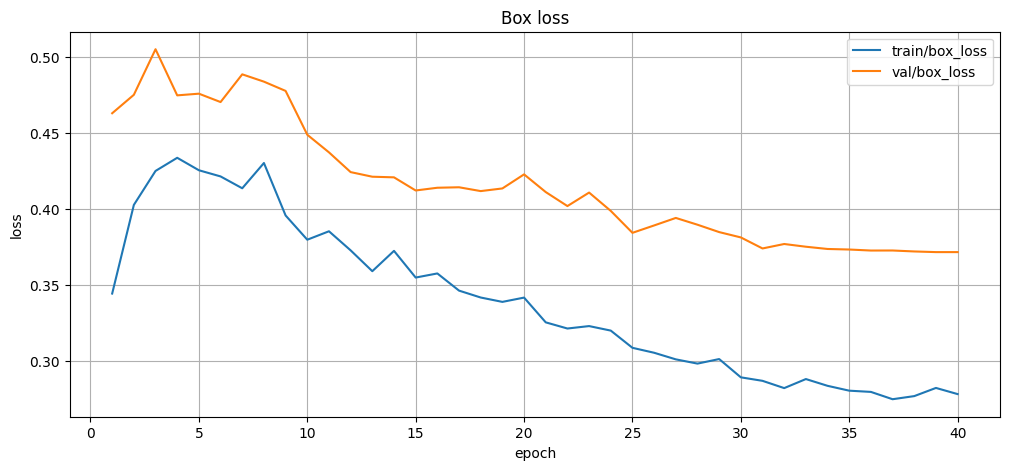

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["epoch"], df["train/box_loss"], label="train/box_loss")
if "val/box_loss" in df.columns:
    plt.plot(df["epoch"], df["val/box_loss"], label="val/box_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Box loss")
plt.grid(True)
plt.legend()
plt.show()

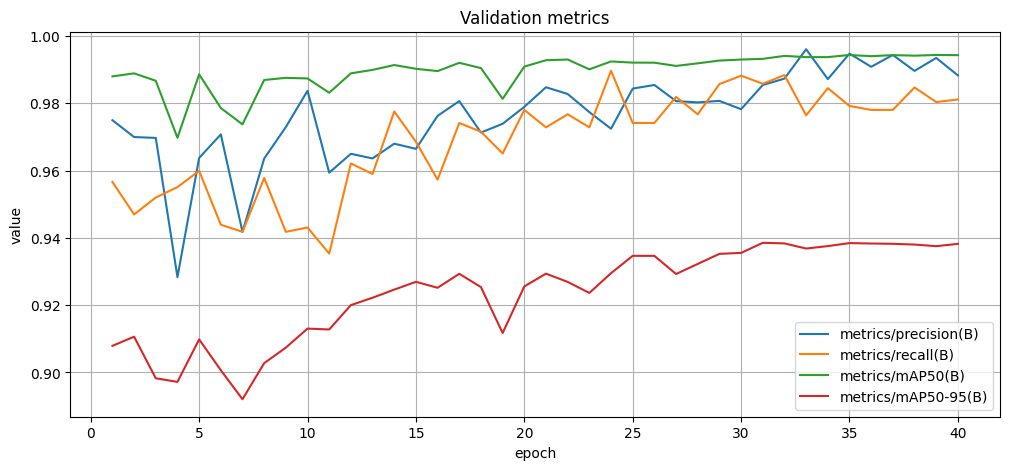

In [ ]:
plt.figure(figsize=(12, 5))

metric_columns = [
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
]

for col in metric_columns:
    if col in df.columns:
        plt.plot(df["epoch"], df[col], label=col)

plt.xlabel("epoch")
plt.ylabel("value")
plt.title("Validation metrics")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
plots_dir = stage2_dir / "custom_plots"
plots_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 5))
plt.plot(df["epoch"], df["train/box_loss"], label="train/box_loss")
if "val/box_loss" in df.columns:
    plt.plot(df["epoch"], df["val/box_loss"], label="val/box_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Box loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(plots_dir / "box_loss.png", dpi=150)
plt.close()

plt.figure(figsize=(12, 5))
for col in metric_columns:
    if col in df.columns:
        plt.plot(df["epoch"], df[col], label=col)
plt.xlabel("epoch")
plt.ylabel("value")
plt.title("Validation metrics")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(plots_dir / "val_metrics.png", dpi=150)
plt.close()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

runs_dir = Path("/content/drive/MyDrive/table_yolo_project/runs")

df1 = pd.read_csv(runs_dir / "tables_stage1" / "results.csv")
df2 = pd.read_csv(runs_dir / "tables_stage2" / "results.csv")

df1.columns = [c.strip() for c in df1.columns]
df2.columns = [c.strip() for c in df2.columns]

# глобальный индекс эпох
df1["epoch_global"] = df1["epoch"]
df2["epoch_global"] = df2["epoch"] + df1["epoch"].max() + 1

plt.figure(figsize=(12, 5))

plt.plot(df1["epoch_global"], df1["train/box_loss"], label="stage1 train/box_loss")
if "val/box_loss" in df1.columns:
    plt.plot(df1["epoch_global"], df1["val/box_loss"], label="stage1 val/box_loss")

plt.plot(df2["epoch_global"], df2["train/box_loss"], label="stage2 train/box_loss")
if "val/box_loss" in df2.columns:
    plt.plot(df2["epoch_global"], df2["val/box_loss"], label="stage2 val/box_loss")

plt.xlabel("global epoch")
plt.ylabel("loss")
plt.title("Box loss: stage1 + stage2")
plt.grid(True)
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/table_yolo_project/runs/tables_stage1/results.csv'